In [1]:
import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ── paths (adjust if your folder names differ) ──────────────────
BASE     = r"C:\Users\Lenovo\Downloads\WORK\EyeMotionID"
MRL_PATH = os.path.join(BASE, "data", "raw", "MRL Eye Dataset")
MPI_PATH = os.path.join(BASE, "data", "raw", "MPIIGAZE", "original")

print("MRL path exists :", os.path.exists(MRL_PATH))
print("MPII path exists:", os.path.exists(MPI_PATH))

MRL path exists : True
MPII path exists: False


In [2]:
import os

MPII_ROOT = r"C:\Users\Lenovo\Downloads\WORK\EyeMotionID\data\raw\MPIIGAZE"

print("=== MPIIGAZE folder contents ===\n")
for root, dirs, files in os.walk(MPII_ROOT):
    dirs[:] = sorted(dirs)
    level = root.replace(MPII_ROOT, "").count(os.sep)
    if level > 3:  # don't go too deep
        continue
    indent = "    " * level + "├── "
    print(f"{indent}{os.path.basename(root)}/")
    if level == 2:
        for f in sorted(files)[:3]:
            print(f"{'    ' * (level+1)}├── {f}")

=== MPIIGAZE folder contents ===

├── MPIIGAZE/
    ├── MPIIGaze/
        ├── Annotation Subset/
            ├── p00.txt
            ├── p01.txt
            ├── p02.txt
        ├── Data/
            ├── Original/
        ├── Evaluation Subset/
            ├── ReadMe.txt
            ├── annotation for face image/
            ├── sample list for eye image/


In [5]:
import os

MRL_PATH = r"C:\Users\Lenovo\Downloads\WORK\EyeMotionID\data\raw\MRL Eye Dataset"

print("=== MRL Eye Dataset — Full Structure ===\n")
for root, dirs, files in os.walk(MRL_PATH):
    dirs[:] = sorted(dirs)
    level = root.replace(MRL_PATH, "").count(os.sep)
    if level > 3:
        continue
    indent = "    " * level + "├── "
    print(f"{indent}{os.path.basename(root)}/")
    # show first 3 files at each level
    for f in sorted(files)[:3]:
        print(f"{'    ' * (level+1)}├── {f}")
    if len(files) > 3:
        print(f"{'    ' * (level+1)}└── ... {len(files)-3} more files")

=== MRL Eye Dataset — Full Structure ===

├── MRL Eye Dataset/
    ├── data/
        ├── get_info.py
        ├── labels.txt
        ├── readme.md
        └── ... 1 more files
        ├── test/
            ├── awake/
                ├── s0001_01846_0_0_1_0_0_01.png
                ├── s0001_01847_0_0_1_0_0_01.png
                ├── s0001_01849_0_0_1_0_0_01.png
                └── ... 8588 more files
            ├── sleepy/
                ├── s0001_00001_0_0_0_0_0_01.png
                ├── s0001_00003_0_0_0_0_0_01.png
                ├── s0001_00004_0_0_0_0_0_01.png
                └── ... 8387 more files
        ├── train/
            ├── awake/
                ├── s0001_01842_0_0_1_0_0_01.png
                ├── s0001_01843_0_0_1_0_0_01.png
                ├── s0001_01845_0_0_1_0_0_01.png
                └── ... 25767 more files
            ├── sleepy/
                ├── s0001_00002_0_0_0_0_0_01.png
                ├── s0001_00005_0_0_0_0_0_01.png
                ├── s0001_00006_0_

In [6]:
import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ── paths ────────────────────────────────────────────────────────
BASE     = r"C:\Users\Lenovo\Downloads\WORK\EyeMotionID"
MRL_PATH = os.path.join(BASE, "data", "raw", "MRL Eye Dataset", "data")  # ← added "data"
MPI_PATH = os.path.join(BASE, "data", "raw", "MPIIGAZE",
                        "MPIIGaze", "Data", "Original")

ext = {".jpg", ".jpeg", ".png", ".bmp"}

print("MRL path exists :", os.path.exists(MRL_PATH))
print("MPII path exists:", os.path.exists(MPI_PATH))

MRL path exists : True
MPII path exists: True


In [7]:
print("=== MRL Eye Dataset ===\n")

grand_total = 0
for split in ["train", "val", "test"]:
    split_path = os.path.join(MRL_PATH, split)
    if not os.path.exists(split_path):
        continue
    print(f"[{split.upper()}]")
    split_total = 0
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path): continue
        count = sum(1 for f in os.listdir(cls_path)
                    if os.path.splitext(f)[1].lower() in ext)
        print(f"  {cls:15s} → {count:,} images")
        split_total += count
    print(f"  {'TOTAL':15s} → {split_total:,} images\n")
    grand_total += split_total

print(f"GRAND TOTAL → {grand_total:,} images")

=== MRL Eye Dataset ===

[TRAIN]
  awake           → 25,770 images
  sleepy          → 25,167 images
  TOTAL           → 50,937 images

[VAL]
  awake           → 8,591 images
  sleepy          → 8,389 images
  TOTAL           → 16,980 images

[TEST]
  awake           → 8,591 images
  sleepy          → 8,390 images
  TOTAL           → 16,981 images

GRAND TOTAL → 84,898 images


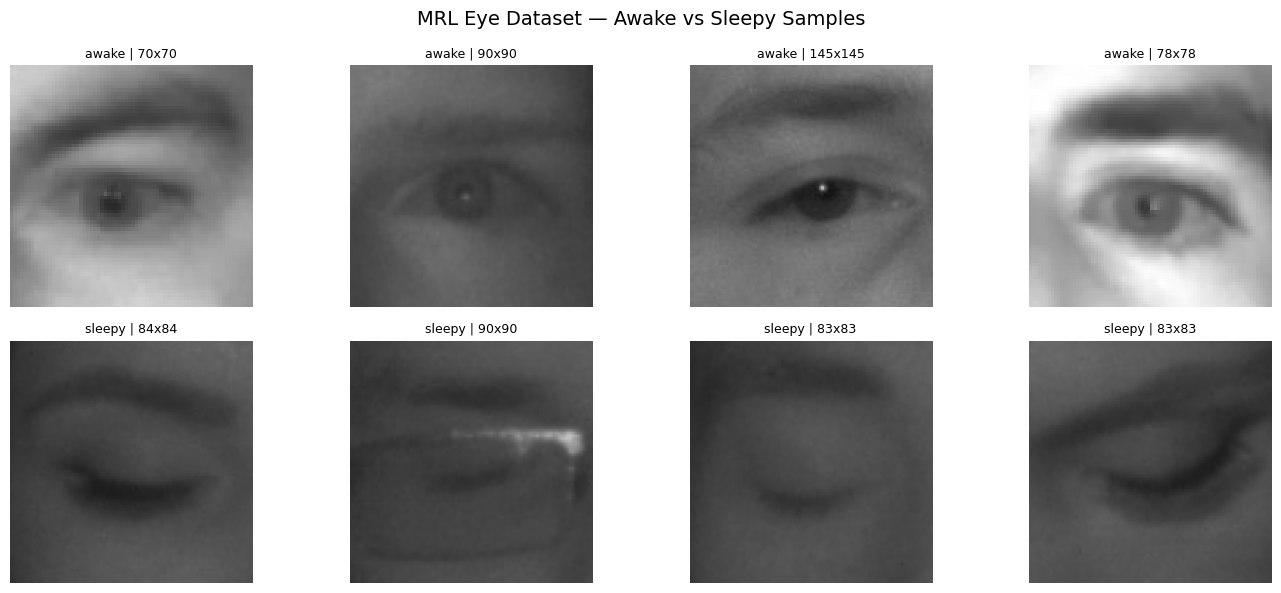

✓ Saved → results/plots/mrl_samples.png


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("MRL Eye Dataset — Awake vs Sleepy Samples", fontsize=14)

for row, cls in enumerate(["awake", "sleepy"]):
    cls_path = os.path.join(MRL_PATH, "train", cls)
    images   = [f for f in os.listdir(cls_path)
                if os.path.splitext(f)[1].lower() in ext]
    samples  = random.sample(images, min(4, len(images)))

    for col, fname in enumerate(samples):
        img = cv2.imread(os.path.join(cls_path, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img)
        axes[row][col].set_title(f"{cls} | {img.shape[1]}x{img.shape[0]}", fontsize=9)
        axes[row][col].axis("off")

plt.tight_layout()
os.makedirs(os.path.join(BASE, "results", "plots"), exist_ok=True)
plt.savefig(os.path.join(BASE, "results", "plots", "mrl_samples.png"), dpi=100)
plt.show()
print("✓ Saved → results/plots/mrl_samples.png")

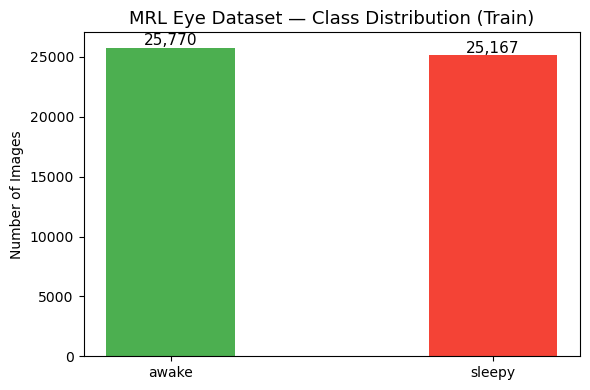

✓ Saved → results/plots/mrl_distribution.png


In [9]:
labels, counts = [], []
for cls in ["awake", "sleepy"]:
    cls_path = os.path.join(MRL_PATH, "train", cls)
    count = sum(1 for f in os.listdir(cls_path)
                if os.path.splitext(f)[1].lower() in ext)
    labels.append(cls)
    counts.append(count)

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, counts, color=["#4CAF50", "#F44336"], width=0.4)
plt.title("MRL Eye Dataset — Class Distribution (Train)", fontsize=13)
plt.ylabel("Number of Images")
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f"{count:,}", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "results", "plots", "mrl_distribution.png"), dpi=100)
plt.show()
print("✓ Saved → results/plots/mrl_distribution.png")

In [10]:
print("=== MPIIGaze Dataset ===\n")
participants = sorted([d for d in os.listdir(MPI_PATH)
                       if os.path.isdir(os.path.join(MPI_PATH, d))])
print(f"Total participants : {len(participants)}")
print(f"Participant IDs    : {participants}\n")

total_images = 0
for p in participants:
    p_path = os.path.join(MPI_PATH, p)
    count  = 0
    days   = [d for d in os.listdir(p_path)
              if os.path.isdir(os.path.join(p_path, d))]
    for day in days:
        day_path = os.path.join(p_path, day)
        count += sum(1 for f in os.listdir(day_path)
                     if os.path.splitext(f)[1].lower() in ext)
    print(f"  {p} → {len(days):2d} days, {count:,} images")
    total_images += count

print(f"\n  TOTAL → {total_images:,} images across {len(participants)} participants")

=== MPIIGaze Dataset ===

Total participants : 15
Participant IDs    : ['p00', 'p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10', 'p11', 'p12', 'p13', 'p14']

  p00 → 40 days, 29,961 images
  p01 → 70 days, 24,143 images
  p02 → 40 days, 28,019 images
  p03 → 66 days, 35,075 images
  p04 → 26 days, 16,831 images
  p05 → 39 days, 16,577 images
  p06 → 63 days, 18,448 images
  p07 → 57 days, 15,509 images
  p08 → 48 days, 10,701 images
  p09 → 21 days, 7,995 images
  p10 → 17 days, 2,810 images
  p11 → 20 days, 2,982 images
  p12 →  8 days, 1,609 images
  p13 → 13 days, 1,498 images
  p14 →  8 days, 1,500 images

  TOTAL → 213,658 images across 15 participants


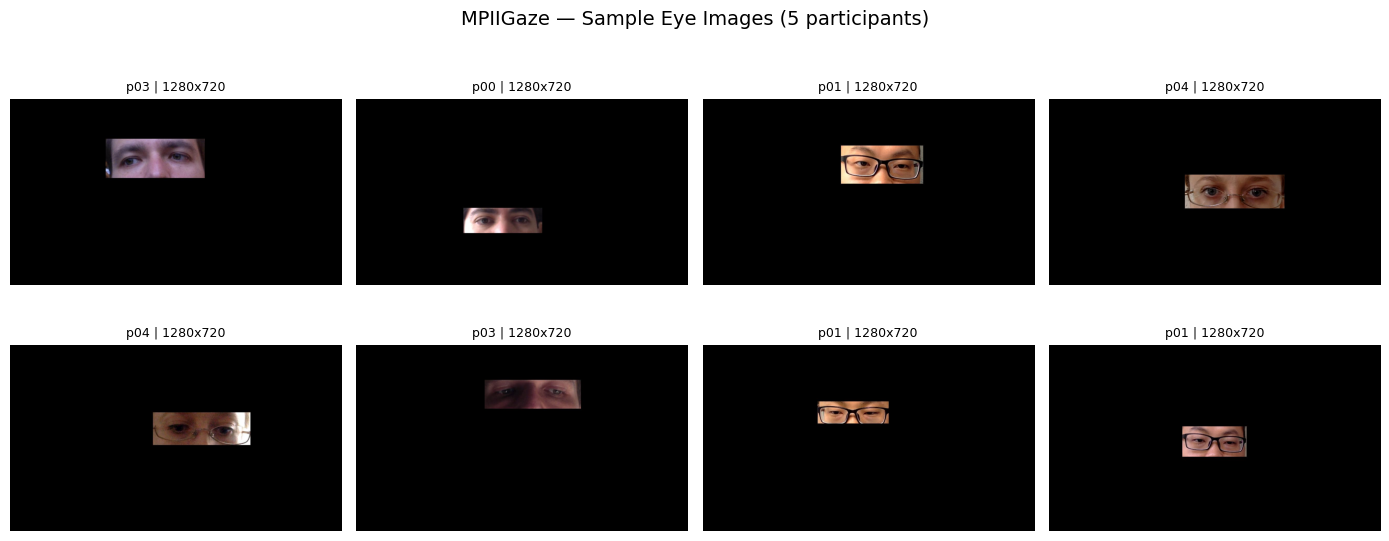

✓ Saved → results/plots/mpii_samples.png


In [11]:
all_images = []
for p in participants[:5]:  # first 5 participants
    p_path = os.path.join(MPI_PATH, p)
    for day in os.listdir(p_path):
        day_path = os.path.join(p_path, day)
        if not os.path.isdir(day_path): continue
        for f in os.listdir(day_path):
            if os.path.splitext(f)[1].lower() in ext:
                all_images.append((p, os.path.join(day_path, f)))

samples = random.sample(all_images, min(8, len(all_images)))

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("MPIIGaze — Sample Eye Images (5 participants)", fontsize=14)

for ax, (pid, path) in zip(axes.flat, samples):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"{pid} | {img.shape[1]}x{img.shape[0]}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(BASE, "results", "plots", "mpii_samples.png"), dpi=100)
plt.show()
print("✓ Saved → results/plots/mpii_samples.png")

In [12]:
print("=" * 45)
print("   DAY 5 DATASET EXPLORATION SUMMARY")
print("=" * 45)
print()
print("Dataset 1 → MRL Eye Dataset")
print("  Classes  : awake (open), sleepy (closed)")
print("  Use in project : blink detection (Week 2)")
print()
print("Dataset 2 → MPIIGaze")
print("  Participants : 15 users")
print("  Structure    : organized by participant + day")
print("  Use in project : gaze tracking + CNN+LSTM training (Week 2 & 3)")
print()
print("Plots saved → results/plots/")
print("  ✓ mrl_samples.png")
print("  ✓ mrl_distribution.png")
print("  ✓ mpii_samples.png")
print()
print("✓ Day 5 complete — ready for Day 6 (OpenEDS)")

   DAY 5 DATASET EXPLORATION SUMMARY

Dataset 1 → MRL Eye Dataset
  Classes  : awake (open), sleepy (closed)
  Use in project : blink detection (Week 2)

Dataset 2 → MPIIGaze
  Participants : 15 users
  Structure    : organized by participant + day
  Use in project : gaze tracking + CNN+LSTM training (Week 2 & 3)

Plots saved → results/plots/
  ✓ mrl_samples.png
  ✓ mrl_distribution.png
  ✓ mpii_samples.png

✓ Day 5 complete — ready for Day 6 (OpenEDS)
